# MultiMed — integrated baseline, NER comparison and correction benchmark

**Release:** `2026-09-14-integrated-benchmark-v2-drive`

Notebook duy nhất cho các luồng `Audio → ASR → NER` và `Audio → ASR → canonical correction → NER`. Mặc định dùng checkpoint PhoBERT đã xác minh, không train lại. Notebook tự mount Google Drive, đọc input từ `MyDrive/MultiMed_inputs` và lưu output vào `MyDrive/MultiMed_outputs`. Chọn GPU T4 trước khi chạy.

## Upload vào Google Drive

Upload toàn bộ nội dung folder `integrated_multimed_inputs/` của project lên:

```text
My Drive/MultiMed_inputs/
├── phobert-best-seed.zip
└── giai_doan_11_text_rulebase/
    ├── canonical_terms.json
    └── canonical_phrases.json
```

Không cần upload các file Python correction rời; logic canonical rulebase đã được nhúng trong notebook.

In [15]:
!pip -q install -U "transformers>=4.41,<5" "datasets>=2.19,<4" accelerate safetensors jiwer soundfile librosa pandas matplotlib tabulate

In [16]:
import gc
import json
import os
import shutil
import time
import zipfile
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
from datasets import Audio, load_dataset
from jiwer import wer
from transformers import (
    AutoFeatureExtractor, AutoModelForSpeechSeq2Seq, AutoModelForTokenClassification,
    AutoProcessor, AutoTokenizer, pipeline,
)

from google.colab import drive
drive.mount('/content/drive')

RELEASE = '2026-09-14-integrated-benchmark-v2-drive'
DRIVE_ROOT = Path('/content/drive/MyDrive')
INPUT_ROOT = DRIVE_ROOT / 'MultiMed_inputs'
OUTPUT_ROOT = DRIVE_ROOT / 'MultiMed_outputs'
if not INPUT_ROOT.exists():
    raise FileNotFoundError(
        f'Không tìm thấy {INPUT_ROOT}. Upload folder integrated_multimed_inputs vào My Drive và đổi tên thành MultiMed_inputs.'
    )
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_TRAIN = False
ACTIVE_NER_MODEL = 'phobert'  # 'phobert' or 'xlm_roberta'
ASR_SMOKE_SAMPLES = 20
ASR_FULL_SAMPLES = 500
RUN_ASR = True
RUN_CORRECTION = True
PHOBERT_ZIP = INPUT_ROOT / 'phobert-best-seed.zip'
PHOBERT_DIR = INPUT_ROOT / 'phobert-vietmed-ner'
RULEBASE_DIR = INPUT_ROOT / 'giai_doan_11_text_rulebase'
XLM_REPO = 'leduckhai/VietMed-NER'
XLM_SUBFOLDER = 'xlm-roberta-base-VietMed-NER'
PHOBERT_BASE = 'vinai/phobert-base-v2'
ASR_REPO = 'leduckhai/MultiMed-ST'
ASR_SUBFOLDER = 'asr/whisper-small-vietnamese/checkpoint-5000'
ASR_PROCESSOR_SUBFOLDER = 'asr/whisper-small-vietnamese'
DATASET_ID = 'leduckhai/VietMed'
NER_DATASET_ID = 'leduckhai/VietMed-NER'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


def to_jsonable(value):
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    return value

print('Release:', RELEASE)
print('Device:', DEVICE)
print('Drive input:', INPUT_ROOT)
print('Drive output:', OUTPUT_ROOT)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Release: 2026-09-14-integrated-benchmark-v2-drive
Device: cuda
Drive input: /content/drive/MyDrive/MultiMed_inputs
Drive output: /content/drive/MyDrive/MultiMed_outputs
GPU: Tesla T4


In [17]:
# Prepare the local PhoBERT checkpoint and canonical rulebase.
if not PHOBERT_DIR.exists() and PHOBERT_ZIP.exists():
    extract_root = INPUT_ROOT / '_phobert_extract'
    extract_root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(PHOBERT_ZIP) as archive:
        archive.extractall(extract_root)
    candidates = [
        p.parent for p in extract_root.rglob('config.json')
        if (p.parent / 'model.safetensors').exists()
        and not p.parent.name.startswith('checkpoint-')
    ]
    if not candidates:
        candidates = [
            p.parent for p in extract_root.rglob('config.json')
            if (p.parent / 'model.safetensors').exists()
        ]
    if not candidates:
        raise FileNotFoundError('Không tìm thấy model.safetensors trong PhoBERT ZIP')
    PHOBERT_DIR = candidates[0]

if not PHOBERT_DIR.exists():
    raise FileNotFoundError(
        'Thiếu PhoBERT checkpoint. Upload phobert-best-seed.zip vào /content/integrated_inputs/'
    )
if not (RULEBASE_DIR / 'canonical_terms.json').exists() or not (RULEBASE_DIR / 'canonical_phrases.json').exists():
    raise FileNotFoundError(
        'Thiếu canonical_terms.json/canonical_phrases.json trong '
        '/content/integrated_inputs/giai_doan_11_text_rulebase/'
    )

terms = json.loads((RULEBASE_DIR / 'canonical_terms.json').read_text(encoding='utf-8'))
phrases = json.loads((RULEBASE_DIR / 'canonical_phrases.json').read_text(encoding='utf-8'))
print('PhoBERT checkpoint:', PHOBERT_DIR)
print('Rulebase terms/phrases:', len(terms), len(phrases))
assert (PHOBERT_DIR / 'config.json').exists()
assert (PHOBERT_DIR / 'model.safetensors').exists()
assert (PHOBERT_DIR / 'tokenizer_config.json').exists()

PhoBERT checkpoint: /content/drive/MyDrive/MultiMed_inputs/_phobert_extract/content/phobert-vietmed-ner/seed_123_lr3e-05_ep8_wd0.05
Rulebase terms/phrases: 1140 20277


In [18]:
# Canonical rulebase: same conservative logic as text_rulebase.py, embedded inline.
import re, unicodedata
_STOPWORDS = {'a','ai','anh','bà','bác','bạn','bệnh','bị','cho','cái','các','có','của','đã','đang','đây','để','được','em','họ','là','mà','một','này','nếu','như','những','nó','ông','rất','sẽ','ta','tại','thì','trong','tôi','và','với','về','xin','khi','nào','theo'}
_PROTECTED = re.compile(r'\d|[/+%=]')
def canonicalize(text): return ' '.join(unicodedata.normalize('NFC', text).split()).strip()
def levenshtein(a, b):
    previous = list(range(len(b) + 1))
    for i, left in enumerate(a, 1):
        current = [i]
        for j, right in enumerate(b, 1): current.append(min(current[-1]+1, previous[j]+1, previous[j-1]+(left != right)))
        previous = current
    return previous[-1]
def comparison_key(value):
    decomposed = unicodedata.normalize('NFD', value.lower())
    return ''.join(c for c in decomposed if unicodedata.category(c) != 'Mn').replace('đ','d')
def similarity(source, target):
    a, b = comparison_key(source), comparison_key(target)
    return 1.0 - levenshtein(a,b) / max(len(a), len(b), 1)
def correct_text(text, terms, phrases, min_similarity=0.86, min_margin=0.08):
    value = canonicalize(text); words = value.split(); changes=[]
    term_map = {x['text']: x for x in terms}; candidates=[(x['text'],x) for x in terms]
    phrase_index={}
    for phrase in phrases:
        if phrase['count'] >= 2:
            pw=phrase['text'].split()
            if not any(w in _STOPWORDS for w in pw): phrase_index.setdefault((len(pw), comparison_key(pw[0])), []).append(phrase)
    i=0
    while i < len(words):
        matched=False
        for size in range(min(5,len(words)-i),1,-1):
            source=' '.join(words[i:i+size]); options=phrase_index.get((size, comparison_key(words[i])), [])
            scored=sorted(
                ((similarity(source,p['text']), p) for p in options if source.lower()!=p['text']),
                key=lambda item: (item[0], item[1].get('count', 0)), reverse=True
            )
            if not scored: continue
            score,p=scored[0]; second=scored[1][0] if len(scored)>1 else 0
            if score >= min_similarity and score-second >= min_margin:
                words[i:i+size]=p['text'].split(); changes.append({'source':source,'target':p['text'],'score':round(score,6),'margin':round(score-second,6),'support':p['count'],'rule':'fuzzy_canonical_phrase'}); i += len(p['text'].split()); matched=True; break
        if matched: continue
        word=words[i]; norm=word.lower()
        if norm not in term_map and len(norm)>=3 and not _PROTECTED.search(norm):
            scored=sorted(
                ((similarity(norm,c), c, m) for c,m in candidates),
                key=lambda item: (item[0], item[2].get('count', 0)), reverse=True
            )
            if scored:
                score,best,meta=scored[0]; second=scored[1][0] if len(scored)>1 else 0
                if score >= 1.0 and score-second >= min_margin and best != norm:
                    words[i]=best; changes.append({'source':word,'target':best,'score':round(score,6),'margin':round(score-second,6),'support':meta['count'],'rule':'fuzzy_canonical_term'})
        i += 1
    return ' '.join(words), changes

assert canonicalize('  đau   đầu  ') == 'đau đầu'
smoke_corrected, smoke_changes = correct_text('chay mau nao', terms, phrases)
assert isinstance(smoke_corrected, str) and isinstance(smoke_changes, list)
print('Rulebase smoke test: passed')

Rulebase smoke test: passed


In [19]:
# Load both NER models and shared inference helpers.
NER_MAX_LENGTH = 256
NER_MODELS = {
    'xlm_roberta': {
        'model': AutoModelForTokenClassification.from_pretrained(XLM_REPO, subfolder=XLM_SUBFOLDER).to(DEVICE),
        'tokenizer': AutoTokenizer.from_pretrained(XLM_REPO, subfolder=XLM_SUBFOLDER),
    },
    'phobert': {
        'model': AutoModelForTokenClassification.from_pretrained(str(PHOBERT_DIR)).to(DEVICE),
        'tokenizer': AutoTokenizer.from_pretrained(str(PHOBERT_DIR)),
    },
}
for values in NER_MODELS.values():
    # The pipeline API differs across Transformers releases; configure length on the tokenizer instead of passing truncation to pipe().
    values['tokenizer'].model_max_length = NER_MAX_LENGTH
NER_PIPES = {
    name: pipeline(
        'ner', model=values['model'], tokenizer=values['tokenizer'],
        aggregation_strategy='simple', device=0 if DEVICE == 'cuda' else -1,
    )
    for name, values in NER_MODELS.items()
}

def entities(pipe, text):
    result = []
    for item in pipe(text):
        label = item.get('entity_group') or item.get('entity')
        if label in {'0', 'O', 'dum'}:
            continue
        start = item.get('start')
        end = item.get('end')
        result.append({
            'text': item['word'], 'label': label,
            'score': round(float(item['score']), 6),
            'start': int(start) if start is not None else None,
            'end': int(end) if end is not None else None,
        })
    return result

def entity_keys(items):
    return Counter((x['text'].strip().lower(), x['label']) for x in items)

def retention(reference, predicted):
    ref, pred = entity_keys(reference), entity_keys(predicted)
    total = sum(ref.values())
    matched = sum((ref & pred).values())
    return {
        'matched': matched,
        'reference_count': total,
        'retention': matched / total if total else None,
    }

def encode_words_for_eval(words, current_tokenizer, max_length=256):
    raw_ids, raw_word_ids = [], []
    for word_index, word in enumerate(words):
        ids = current_tokenizer.encode(word, add_special_tokens=False)
        raw_ids.extend(ids)
        raw_word_ids.extend([word_index] * len(ids))
    input_ids = current_tokenizer.build_inputs_with_special_tokens(raw_ids)
    raw_start = None
    for start in range(len(input_ids) - len(raw_ids) + 1):
        if input_ids[start:start + len(raw_ids)] == raw_ids:
            raw_start = start
            break
    if raw_start is None:
        raise ValueError('Could not locate raw tokens in special-token sequence')
    input_ids = input_ids[:max_length]
    raw_end = min(raw_start + len(raw_ids), len(input_ids))
    aligned_word_ids = [None] * len(input_ids)
    for raw_index, position in enumerate(range(raw_start, raw_end)):
        aligned_word_ids[position] = raw_word_ids[raw_index]
    return {'input_ids': input_ids, 'attention_mask': [1] * len(input_ids)}, aligned_word_ids

def active_ner_pipe():
    if ACTIVE_NER_MODEL not in NER_PIPES:
        raise ValueError(f"ACTIVE_NER_MODEL must be one of {sorted(NER_PIPES)}")
    return NER_PIPES[ACTIVE_NER_MODEL]

print('NER models loaded:', sorted(NER_PIPES))
print('Active production model:', ACTIVE_NER_MODEL)
print('NER max length:', NER_MAX_LENGTH)

Device set to use cuda:0
Device set to use cuda:0


NER models loaded: ['phobert', 'xlm_roberta']
Active production model: phobert
NER max length: 256


In [20]:
# Gold benchmark on the official test split, using an inline BIO entity evaluator.
# No external NER metric package is required on Colab Python 3.13.
ner_gold = load_dataset(NER_DATASET_ID, split='test')

def bio_entities(tags):
    entities = set()
    current_type = None
    start = None
    for index, raw_tag in enumerate(tags + ['O']):
        tag = str(raw_tag)
        if tag in {'O', '0', 'dum'}:
            prefix, entity_type = 'O', None
        elif '-' in tag:
            prefix, entity_type = tag.split('-', 1)
        else:
            prefix, entity_type = 'B', tag
        starts_new = prefix == 'B' or (prefix == 'I' and entity_type != current_type)
        if current_type is not None and (starts_new or entity_type is None):
            entities.add((current_type, start, index))
            current_type, start = None, None
        if starts_new:
            current_type, start = entity_type, index
    return entities

def span_metrics(gold_sequences, predicted_sequences):
    gold_total = sum(len(bio_entities(tags)) for tags in gold_sequences)
    predicted_total = sum(len(bio_entities(tags)) for tags in predicted_sequences)
    matched = sum(
        len(bio_entities(gold) & bio_entities(predicted))
        for gold, predicted in zip(gold_sequences, predicted_sequences)
    )
    precision = matched / predicted_total if predicted_total else 0.0
    recall = matched / gold_total if gold_total else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {'precision': precision, 'recall': recall, 'f1': f1, 'matched': matched, 'gold_entities': gold_total, 'predicted_entities': predicted_total}

def gold_sequences(model, tok, examples):
    model.eval()
    model_id2label = {int(k): v for k, v in model.config.id2label.items()}
    predicted_all, gold_all = [], []
    for example in examples:
        encoded, aligned_word_ids = encode_words_for_eval(example['words'], tok)
        model_inputs = {
            key: torch.tensor([value], dtype=torch.long, device=DEVICE)
            for key, value in encoded.items()
        }
        with torch.inference_mode():
            logits = model(**model_inputs).logits
        predicted_ids = logits.argmax(dim=-1)[0].detach().cpu().tolist()
        predicted_tags, gold_tags, seen_words = [], [], set()
        for predicted_id, word_id in zip(predicted_ids, aligned_word_ids):
            if word_id is None or word_id in seen_words:
                continue
            if word_id >= len(example['labels']):
                break
            seen_words.add(word_id)
            predicted_tags.append(model_id2label[int(predicted_id)])
            gold_tags.append(str(example['labels'][word_id]))
        predicted_all.append(predicted_tags)
        gold_all.append(gold_tags)
    return gold_all, predicted_all

gold_metrics = []
for name, values in NER_MODELS.items():
    gold, predicted = gold_sequences(values['model'], values['tokenizer'], ner_gold)
    metrics = span_metrics(gold, predicted)
    gold_metrics.append({'model': name, 'num_examples': len(gold), **metrics})
gold_metrics = to_jsonable(gold_metrics)
Path(OUTPUT_ROOT / 'gold_metrics.json').write_text(
    json.dumps(gold_metrics, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(pd.DataFrame([{k: v for k, v in row.items() if k not in {'gold_entities', 'predicted_entities'}} for row in gold_metrics]).to_string(index=False))

      model  num_examples  precision   recall       f1  matched
xlm_roberta          3497   0.525800 0.662389 0.586243     5523
    phobert          3497   0.567255 0.693931 0.624231     5786


In [21]:
# Text correction benchmark on validation only; test remains reserved for gold benchmark.
text_validation = load_dataset(NER_DATASET_ID, split='validation')
text_benchmark = []
for example in text_validation:
    text = ' '.join(example['words']) if isinstance(example.get('words'), list) else str(example.get('text', ''))
    corrected, changes = correct_text(text, terms, phrases) if RUN_CORRECTION else (text, [])
    text_benchmark.append({
        'text': text,
        'corrected_text': corrected,
        'changed': bool(changes),
        'changes': changes,
        'active_model': ACTIVE_NER_MODEL,
        'active_direct_entities': entities(active_ner_pipe(), text),
        'active_corrected_entities': entities(active_ner_pipe(), corrected),
        'xlm_direct': entities(NER_PIPES['xlm_roberta'], text),
        'xlm_corrected': entities(NER_PIPES['xlm_roberta'], corrected),
        'phobert_direct': entities(NER_PIPES['phobert'], text),
        'phobert_corrected': entities(NER_PIPES['phobert'], corrected),
    })
Path(OUTPUT_ROOT / 'text_correction_results.jsonl').write_text(
    ''.join(json.dumps(x, ensure_ascii=False) + '\n' for x in text_benchmark),
    encoding='utf-8',
)
text_summary = {
    'split': 'validation',
    'num_examples': len(text_benchmark),
    'changed_examples': sum(x['changed'] for x in text_benchmark),
    'total_rule_changes': sum(len(x['changes']) for x in text_benchmark),
    'active_model': ACTIVE_NER_MODEL,
    'note': 'Text-only/validation benchmark; synthetic rulebase precision is not real-ASR evidence.',
}
(OUTPUT_ROOT / 'text_correction_summary.json').write_text(
    json.dumps(text_summary, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(json.dumps(text_summary, ensure_ascii=False, indent=2))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


{
  "split": "validation",
  "num_examples": 1154,
  "changed_examples": 1025,
  "total_rule_changes": 2506,
  "active_model": "phobert",
  "note": "Text-only/validation benchmark; synthetic rulebase precision is not real-ASR evidence."
}


In [22]:
# ASR smoke 20, then full 500 only if smoke passes. ASR is run once per audio.
from transformers import AutoFeatureExtractor, AutoModelForSpeechSeq2Seq, AutoProcessor
if RUN_ASR:
    if not torch.cuda.is_available():
        raise RuntimeError('ASR benchmark requires a CUDA/T4 runtime')
    asr_model = AutoModelForSpeechSeq2Seq.from_pretrained(
        ASR_REPO, subfolder=ASR_SUBFOLDER, dtype=torch.float16,
        low_cpu_mem_usage=True, use_safetensors=True,
    ).to('cuda')
    processor = AutoProcessor.from_pretrained(ASR_REPO, subfolder=ASR_PROCESSOR_SUBFOLDER)
    asr_tok = getattr(processor, 'tokenizer', processor)
    asr_feat = getattr(processor, 'feature_extractor', None)
    if asr_feat is None:
        asr_feat = AutoFeatureExtractor.from_pretrained(ASR_REPO, subfolder=ASR_PROCESSOR_SUBFOLDER)
    asr_pipe = pipeline(
        'automatic-speech-recognition', model=asr_model,
        tokenizer=asr_tok, feature_extractor=asr_feat,
        dtype=torch.float16, device=0,
    )
    audio_ds = load_dataset(DATASET_ID, split='test').cast_column(
        'audio', Audio(sampling_rate=16000, decode=True)
    )
    def run_audio(n):
        records = []
        for idx, row in enumerate(audio_ds.select(range(min(n, len(audio_ds))))):
            audio = row['audio']
            result = asr_pipe(
                {'raw': audio['array'], 'sampling_rate': audio['sampling_rate']},
                generate_kwargs={'language': 'Vietnamese', 'task': 'transcribe'},
            )
            transcript = result['text'].strip()
            reference = row.get('text', '') or ''
            corrected, changes = correct_text(transcript, terms, phrases) if RUN_CORRECTION else (transcript, [])
            output = {
                'index': idx, 'active_model': ACTIVE_NER_MODEL,
                'reference_transcript': reference, 'asr_transcript': transcript,
                'corrected_transcript': corrected,
                'wer_asr': float(wer(reference, transcript)) if reference and transcript else None,
                'wer_corrected': float(wer(reference, corrected)) if reference and corrected else None,
                'correction_changes': changes,
            }
            for model_name, ner_pipe in NER_PIPES.items():
                ref_ent = entities(ner_pipe, reference)
                asr_ent = entities(ner_pipe, transcript)
                cor_ent = entities(ner_pipe, corrected)
                output[model_name] = {
                    'reference_entities': ref_ent, 'asr_entities': asr_ent,
                    'corrected_entities': cor_ent,
                    'asr_retention': retention(ref_ent, asr_ent),
                    'corrected_retention': retention(ref_ent, cor_ent),
                }
            records.append(output)
            if (idx + 1) % 10 == 0:
                print('ASR progress', idx + 1, n)
        return records
    smoke_records = run_audio(ASR_SMOKE_SAMPLES)
    assert len(smoke_records) == ASR_SMOKE_SAMPLES
    print('Smoke passed; starting full batch')
    asr_records = run_audio(ASR_FULL_SAMPLES)
    (OUTPUT_ROOT / 'asr_correction_comparison.jsonl').write_text(
        ''.join(json.dumps(x, ensure_ascii=False) + '\n' for x in asr_records),
        encoding='utf-8',
    )
else:
    asr_records = []
    print('ASR disabled')

config.json: 0.00B [00:00, ?B/s]

asr/whisper-small-vietnamese/checkpoint-(…):   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Generating dev split:   0%|          | 0/2912 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3437 [00:00<?, ? examples/s]

Generating cv split:   0%|          | 0/85 [00:00<?, ? examples/s]

`return_token_timestamps` is deprecated for WhisperFeatureExtractor and will be removed in Transformers v5. Use `return_attention_mask` instead, as the number of frames can be inferred from it.


ASR progress 10 20
ASR progress 20 20
Smoke passed; starting full batch
ASR progress 10 500
ASR progress 20 500
ASR progress 30 500
ASR progress 40 500
ASR progress 50 500
ASR progress 60 500
ASR progress 70 500
ASR progress 80 500
ASR progress 90 500
ASR progress 100 500
ASR progress 110 500
ASR progress 120 500
ASR progress 130 500
ASR progress 140 500
ASR progress 150 500
ASR progress 160 500
ASR progress 170 500
ASR progress 180 500
ASR progress 190 500
ASR progress 200 500
ASR progress 210 500
ASR progress 220 500
ASR progress 230 500
ASR progress 240 500
ASR progress 250 500
ASR progress 260 500
ASR progress 270 500
ASR progress 280 500
ASR progress 290 500
ASR progress 300 500
ASR progress 310 500
ASR progress 320 500
ASR progress 330 500
ASR progress 340 500
ASR progress 350 500
ASR progress 360 500
ASR progress 370 500
ASR progress 380 500
ASR progress 390 500
ASR progress 400 500
ASR progress 410 500
ASR progress 420 500
ASR progress 430 500
ASR progress 440 500
ASR progress 

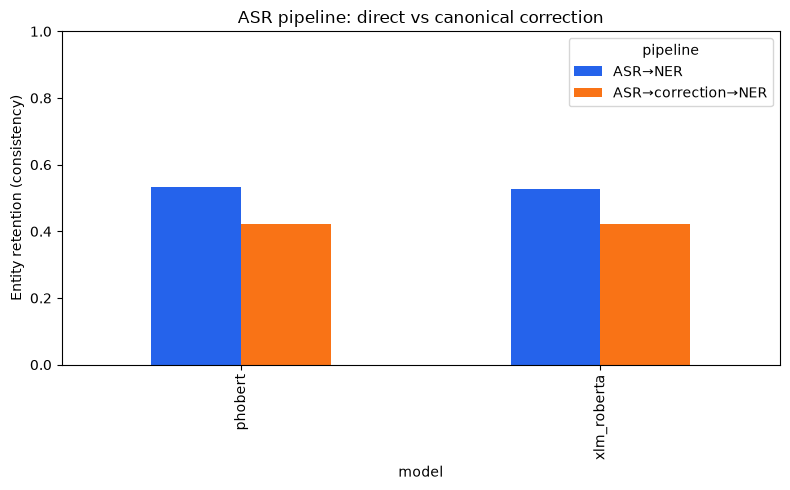

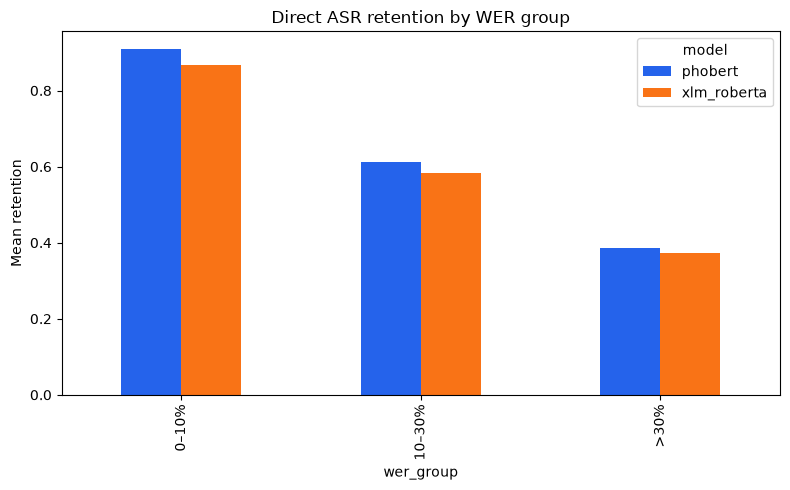

Drive output: /content/drive/MyDrive/MultiMed_outputs
Drive ZIP: /content/drive/MyDrive/multimed_integrated_results.zip
Outputs: ['asr_correction_comparison.jsonl', 'case_studies.json', 'experiment_manifest.json', 'gold_metrics.json', 'pipeline_retention.png', 'pipeline_summary.csv', 'pipeline_summary.md', 'retention_by_wer.png', 'text_correction_results.jsonl', 'text_correction_summary.json']


In [23]:
# Tables, charts, case studies, manifest and Drive backup.
summary = []
for model_name in ['xlm_roberta', 'phobert']:
    if asr_records:
        direct = sum(r[model_name]['asr_retention']['matched'] for r in asr_records)
        direct_ref = sum(r[model_name]['asr_retention']['reference_count'] for r in asr_records)
        corrected = sum(r[model_name]['corrected_retention']['matched'] for r in asr_records)
        corrected_ref = sum(r[model_name]['corrected_retention']['reference_count'] for r in asr_records)
        summary.extend([
            {'model': model_name, 'pipeline': 'ASR→NER', 'retention': direct / direct_ref if direct_ref else None, 'matched': direct, 'reference_entities': direct_ref},
            {'model': model_name, 'pipeline': 'ASR→correction→NER', 'retention': corrected / corrected_ref if corrected_ref else None, 'matched': corrected, 'reference_entities': corrected_ref},
        ])
summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUTPUT_ROOT / 'pipeline_summary.csv', index=False)
(OUTPUT_ROOT / 'pipeline_summary.md').write_text(summary_df.to_markdown(index=False), encoding='utf-8')

import matplotlib.pyplot as plt
if not summary_df.empty:
    ax = summary_df.pivot(index='model', columns='pipeline', values='retention').plot(kind='bar', color=['#2563EB', '#F97316'], figsize=(8, 5))
    ax.set_ylabel('Entity retention (consistency)'); ax.set_title('ASR pipeline: direct vs canonical correction'); ax.set_ylim(0, 1)
    ax.figure.tight_layout(); ax.figure.savefig(OUTPUT_ROOT / 'pipeline_retention.png', dpi=180); plt.show()
if asr_records:
    rows = []
    for record in asr_records:
        for model_name in ['xlm_roberta', 'phobert']:
            rows.append({'wer': record['wer_asr'], 'model': model_name, 'direct': record[model_name]['asr_retention']['retention'], 'corrected': record[model_name]['corrected_retention']['retention']})
    plot_df = pd.DataFrame(rows)
    plot_df['wer_group'] = pd.cut(plot_df['wer'], [-0.001, 0.1, 0.3, 1], labels=['0–10%', '10–30%', '>30%'])
    grouped = plot_df.groupby(['wer_group', 'model'], observed=False)['direct'].mean().unstack()
    grouped.plot(kind='bar', figsize=(8, 5), color=['#2563EB', '#F97316'])
    plt.ylabel('Mean retention'); plt.title('Direct ASR retention by WER group'); plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'retention_by_wer.png', dpi=180); plt.show()
    cases = sorted(asr_records, key=lambda r: (r['wer_asr'] or 0), reverse=True)[:10]
    (OUTPUT_ROOT / 'case_studies.json').write_text(json.dumps(cases, ensure_ascii=False, indent=2), encoding='utf-8')

manifest = {
    'release': RELEASE, 'active_model': ACTIVE_NER_MODEL, 'run_train': RUN_TRAIN,
    'run_correction': RUN_CORRECTION, 'asr_smoke_samples': ASR_SMOKE_SAMPLES,
    'asr_full_samples': len(asr_records), 'drive_input': str(INPUT_ROOT),
    'drive_output': str(OUTPUT_ROOT), 'rulebase_dir': str(RULEBASE_DIR),
    'models': {'xlm_roberta': XLM_REPO + '/' + XLM_SUBFOLDER, 'phobert': str(PHOBERT_DIR)},
    'notes': ['Gold F1 is a benchmark metric.', 'Entity retention is consistency, not gold recall.', 'Canonical rulebase synthetic precision is not real-ASR correction evidence.'],
}
(OUTPUT_ROOT / 'experiment_manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')
archive_path = DRIVE_ROOT / 'multimed_integrated_results.zip'
if archive_path.exists(): archive_path.unlink()
shutil.make_archive(str(DRIVE_ROOT / 'multimed_integrated_results'), 'zip', OUTPUT_ROOT)
print('Drive output:', OUTPUT_ROOT)
print('Drive ZIP:', archive_path)
print('Outputs:', sorted(p.name for p in OUTPUT_ROOT.iterdir()))